# Tiền xử lý và chuẩn bị dữ liệu
## Phát hiện gian lận thẻ tín dụng với Apache Spark

**Dataset:** Sparkov Credit Card Fraud Detection  
**Công cụ:** PySpark, Matplotlib, Seaborn

---

## Setup

In [63]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("FraudDetection_Preprocessing") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print("Spark version:", spark.version)

Spark version: 4.1.1


---
## Load dữ liệu

In [64]:
train_df = spark.read.csv("data/fraudTrain.csv", header=True, inferSchema=True)
test_df = spark.read.csv("data/fraudTest.csv", header=True, inferSchema=True)

train_df = train_df.withColumn("trans_date_trans_time", F.to_timestamp("trans_date_trans_time", "yyyy-MM-dd HH:mm:ss")) \
                    .withColumn("dob", F.to_date("dob", "yyyy-MM-dd"))
test_df = test_df.withColumn("trans_date_trans_time", F.to_timestamp("trans_date_trans_time", "yyyy-MM-dd HH:mm:ss")) \
                  .withColumn("dob", F.to_date("dob", "yyyy-MM-dd"))

train_total = train_df.count()
test_total = test_df.count()
print(f"Train: {train_total:,} dòng, {len(train_df.columns)} cột")
print(f"Test:  {test_total:,} dòng, {len(test_df.columns)} cột")

Train: 1,296,675 dòng, 23 cột
Test:  555,719 dòng, 23 cột


---
## Lưu bản raw


In [65]:
cols_to_drop_raw = [
    "_c0", "first", "last", "street", "cc_num", "trans_num",
    "trans_date_trans_time", "dob",
]

train_raw = train_df.drop(*cols_to_drop_raw)
test_raw = test_df.drop(*cols_to_drop_raw)

print(f"Train raw: {train_raw.count():,} dòng, {len(train_raw.columns)} cột")
print(f"Test raw:  {test_raw.count():,} dòng, {len(test_raw.columns)} cột")
print(f"Các cột: {train_raw.columns}")

Train raw: 1,296,675 dòng, 15 cột
Test raw:  555,719 dòng, 15 cột
Các cột: ['merchant', 'category', 'amt', 'gender', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


---
## Xử lý Outlier — Amount

In [66]:
quantiles = train_df.approxQuantile("amt", [0.25, 0.75], 0.01)
Q1, Q3 = quantiles[0], quantiles[1]
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"IQR bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")

outlier_train = train_df.filter((F.col("amt") < lower_bound) | (F.col("amt") > upper_bound)).count()
outlier_test = test_df.filter((F.col("amt") < lower_bound) | (F.col("amt") > upper_bound)).count()
print(f"Outlier train: {outlier_train:,} ({outlier_train/train_total*100:.2f}%)")
print(f"Outlier test:  {outlier_test:,} ({outlier_test/test_total*100:.2f}%)")

train_df = train_df.withColumn("amt",
    F.when(F.col("amt") > upper_bound, upper_bound)
     .when(F.col("amt") < lower_bound, lower_bound)
     .otherwise(F.col("amt")))

test_df = test_df.withColumn("amt",
    F.when(F.col("amt") > upper_bound, upper_bound)
     .when(F.col("amt") < lower_bound, lower_bound)
     .otherwise(F.col("amt")))

print(f"\nSau capping:")
print(f"Train amt range: [{train_df.agg(F.min('amt')).first()[0]:.2f}, {train_df.agg(F.max('amt')).first()[0]:.2f}]")
print(f"Test  amt range: [{test_df.agg(F.min('amt')).first()[0]:.2f}, {test_df.agg(F.max('amt')).first()[0]:.2f}]")

IQR bounds: [-100.15, 192.01]
Outlier train: 68,416 (5.28%)
Outlier test:  28,172 (5.07%)

Sau capping:
Train amt range: [1.00, 192.01]
Test  amt range: [1.00, 192.01]


---
## Feature Engineering
Tạo các đặc trưng mới từ dữ liệu gốc. Tất cả đều tính từ chính dòng đó, train và test tính độc lập.

In [67]:
train_df = train_df \
    .withColumn("hour", F.hour("trans_date_trans_time")) \
    .withColumn("day_of_week", F.dayofweek("trans_date_trans_time")) \
    .withColumn("month", F.month("trans_date_trans_time"))

test_df = test_df \
    .withColumn("hour", F.hour("trans_date_trans_time")) \
    .withColumn("day_of_week", F.dayofweek("trans_date_trans_time")) \
    .withColumn("month", F.month("trans_date_trans_time"))

train_df = train_df.withColumn("age", F.floor(F.datediff("trans_date_trans_time", "dob") / 365.25))
test_df = test_df.withColumn("age", F.floor(F.datediff("trans_date_trans_time", "dob") / 365.25))

invalid_age_train = train_df.filter((F.col("age") < 0) | (F.col("age") > 120) | F.col("age").isNull()).count()
invalid_age_test = test_df.filter((F.col("age") < 0) | (F.col("age") > 120) | F.col("age").isNull()).count()
print(f"Tuổi không hợp lệ — Train: {invalid_age_train}, Test: {invalid_age_test}")

def add_distance(df):
    return df.withColumn("distance_km",
        6371 * 2 * F.asin(F.sqrt(
            F.pow(F.sin(F.radians(F.col("merch_lat") - F.col("lat")) / 2), 2) +
            F.cos(F.radians("lat")) * F.cos(F.radians("merch_lat")) *
            F.pow(F.sin(F.radians(F.col("merch_long") - F.col("long")) / 2), 2)
        ))
    )

train_df = add_distance(train_df)
test_df = add_distance(test_df)

print("\nFeatures mới:")
train_df.select("hour", "day_of_week", "month", "age", "distance_km").show(5)

Tuổi không hợp lệ — Train: 0, Test: 0

Features mới:
+----+-----------+-----+---+------------------+
|hour|day_of_week|month|age|       distance_km|
+----+-----------+-----+---+------------------+
|   0|          3|    1| 30| 78.59756848823127|
|   0|          3|    1| 40| 30.21217571921031|
|   0|          3|    1| 56|108.20608258720077|
|   0|          3|    1| 51| 95.67323113819798|
|   0|          3|    1| 32| 77.55674362581732|
+----+-----------+-----+---+------------------+
only showing top 5 rows


---
## Loại bỏ cột không cần thiết

In [ ]:
cols_to_drop = [
    "_c0", "first", "last", "street",
    "cc_num", "trans_num",
    "unix_time", "trans_date_trans_time", "dob",
    "lat", "long", "merch_lat", "merch_long",
]

train_df = train_df.drop(*cols_to_drop)
test_df = test_df.drop(*cols_to_drop)

print("\nCác cột còn lại:")
print(train_df.columns)
print(f"Số cột: {len(train_df.columns)}")

---
## Phân tích tương quan (Correlation Matrix)

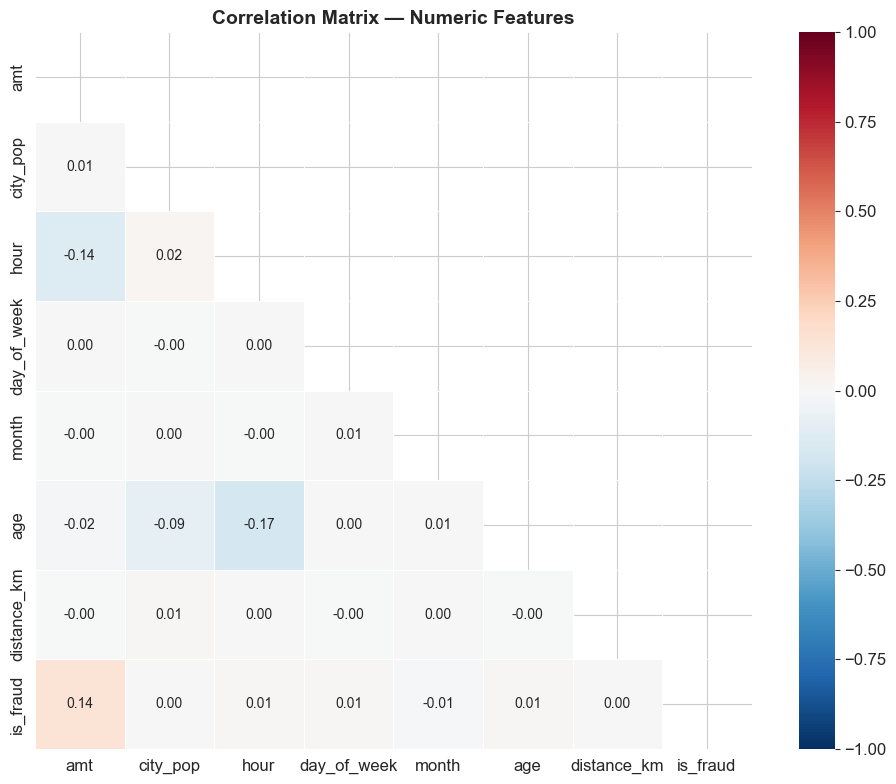

In [69]:
numeric_features = [
    "amt", "city_pop", "hour", "day_of_week", "month", "age", "distance_km", "is_fraud"
]

corr_assembler = VectorAssembler(inputCols=numeric_features, outputCol="corr_features", handleInvalid="skip")
corr_df = corr_assembler.transform(train_df).select("corr_features")

corr_result = Correlation.corr(corr_df, "corr_features", "pearson")
corr_array = corr_result.head()[0].toArray()
corr_matrix = pd.DataFrame(corr_array, index=numeric_features, columns=numeric_features)

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            ax=ax, annot_kws={'size': 10})
ax.set_title('Correlation Matrix — Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [70]:
corr_with_fraud = corr_matrix["is_fraud"].drop("is_fraud").abs().sort_values(ascending=False)
print("Correlation với is_fraud (|r|):")
print(corr_with_fraud.to_string())

Correlation với is_fraud (|r|):
amt            0.135665
hour           0.013799
month          0.012409
age            0.012251
day_of_week    0.009620
city_pop       0.002136
distance_km    0.000403


In [71]:
threshold = 0.7
high_corr_pairs = []
cols = corr_matrix.columns.tolist()
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if cols[i] == "is_fraud" or cols[j] == "is_fraud":
            continue
        r = abs(corr_matrix.iloc[i, j])
        if r > threshold:
            high_corr_pairs.append((cols[i], cols[j], round(r, 3)))

if high_corr_pairs:
    print(f"Cặp feature có |r| > {threshold}:")
    for f1, f2, r in sorted(high_corr_pairs, key=lambda x: -x[2]):
        print(f"  {f1} — {f2}: {r}")
else:
    print(f"Không có cặp feature nào có |r| > {threshold}")

Không có cặp feature nào có |r| > 0.7


### Kiểm tra đa cộng tuyến (VIF)
VIF đo mức độ 1 biến bị giải thích bởi các biến còn lại.
- VIF ≤ 5: chấp nhận được
- VIF 5–10: cộng tuyến vừa
- VIF > 10: cộng tuyến nghiêm trọng

In [73]:
from pyspark.ml.regression import LinearRegression

numeric_cols = ["amt", "city_pop", "hour", "day_of_week", "month", "age", "distance_km"]

vif_results = []
for col in numeric_cols:
    other_cols = [c for c in numeric_cols if c != col]
    assembler = VectorAssembler(inputCols=other_cols, outputCol="vif_features", handleInvalid="skip")
    vif_df = assembler.transform(train_df).select("vif_features", F.col(col).alias("label"))
    
    lr = LinearRegression(featuresCol="vif_features", labelCol="label")
    lr_model = lr.fit(vif_df)
    r2 = lr_model.summary.r2
    vif = 1 / (1 - r2) if r2 < 1 else float('inf')
    vif_results.append({"Feature": col, "R²": round(r2, 4), "VIF": round(vif, 2)})

vif_df_pd = pd.DataFrame(vif_results).sort_values("VIF", ascending=False)
print("VIF — Kiểm tra đa cộng tuyến:")
print(vif_df_pd.to_string(index=False))

high_vif = vif_df_pd[vif_df_pd['VIF'] > 5]
if len(high_vif) > 0:
    print(f"\n⚠️ Có {len(high_vif)} feature VIF > 5:")
    for _, row in high_vif.iterrows():
        print(f"  {row['Feature']}: VIF = {row['VIF']}")
else:
    print("\n Tất cả feature đều VIF ≤ 5, không có đa cộng tuyến nghiêm trọng.")

VIF — Kiểm tra đa cộng tuyến:
    Feature     R²  VIF
       hour 0.0494 1.05
        age 0.0400 1.04
        amt 0.0206 1.02
   city_pop 0.0087 1.01
day_of_week 0.0001 1.00
      month 0.0001 1.00
distance_km 0.0001 1.00

Tất cả feature đều VIF ≤ 5, không có đa cộng tuyến nghiêm trọng.


---
## Feature Selection

In [57]:
cols_to_drop_model = ["zip"]

train_model = train_df.drop(*cols_to_drop_model)
test_model = test_df.drop(*cols_to_drop_model)

print("Feature cuối cùng:")
feature_cols = [c for c in train_model.columns if c != "is_fraud"]
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")
print(f"\nTổng: {len(feature_cols)} features")

Feature cuối cùng:
   1. merchant
   2. category
   3. amt
   4. gender
   5. city
   6. state
   7. city_pop
   8. job
   9. hour
  10. day_of_week
  11. month
  12. age
  13. distance_km

Tổng: 13 features
(category, gender, state, merchant, city, job sẽ được encode ở Bước 3 — Training)


---
## Xử lý Imbalanced Data — Class Weight

In [58]:
train_model.groupBy("is_fraud").count().show()

fraud_count = train_model.filter(F.col("is_fraud") == 1).count()
nonfraud_count = train_model.filter(F.col("is_fraud") == 0).count()
ratio = nonfraud_count / fraud_count
print(f"Fraud: {fraud_count:,} | Non-fraud: {nonfraud_count:,} | Ratio: 1:{ratio:.0f}")

total = fraud_count + nonfraud_count
weight_fraud = total / (2 * fraud_count)
weight_nonfraud = total / (2 * nonfraud_count)
print(f"\nClass weights — fraud: {weight_fraud:.2f}, non-fraud: {weight_nonfraud:.2f}")

train_model = train_model.withColumn("weight",
    F.when(F.col("is_fraud") == 1, weight_fraud).otherwise(weight_nonfraud))

train_model.groupBy("is_fraud").agg(
    F.count("*").alias("count"),
    F.first("weight").alias("weight")
).show()

+--------+-------+
|is_fraud|  count|
+--------+-------+
|       1|   7506|
|       0|1289169|
+--------+-------+

Fraud: 7,506 | Non-fraud: 1,289,169 | Ratio: 1:172

Class weights — fraud: 86.38, non-fraud: 0.50
+--------+-------+------------------+
|is_fraud|  count|            weight|
+--------+-------+------------------+
|       1|   7506| 86.37589928057554|
|       0|1289169|0.5029111776656126|
+--------+-------+------------------+



---
## Xuất dữ liệu

In [59]:
numeric_check = ["amt", "city_pop", "hour", "day_of_week", "month", "age", "distance_km"]

for df_name, df in [("train_model", train_model), ("test_model", test_model)]:
    null_count = df.select([F.sum((F.col(c).isNull() | F.isnan(c)).cast("int")).alias(c) for c in numeric_check])
    nulls = null_count.first().asDict()
    has_null = {k: v for k, v in nulls.items() if v > 0}
    if has_null:
        print(f"[!] {df_name} có null: {has_null}")
    else:
        print(f"[OK] {df_name}: không có null")

✓ train_model: không có null trong feature columns
✓ test_model: không có null trong feature columns


In [60]:
import os
output_dir = "models/preprocessing"
os.makedirs(output_dir, exist_ok=True)

train_raw.write.parquet(f"{output_dir}/train_raw.parquet", mode="overwrite")
test_raw.write.parquet(f"{output_dir}/test_raw.parquet", mode="overwrite")
train_model.write.parquet(f"{output_dir}/train_processed.parquet", mode="overwrite")
test_model.write.parquet(f"{output_dir}/test_processed.parquet", mode="overwrite")

print("Đã xuất 4 file:")
print(f"  train_raw.parquet       ({train_raw.count():,} dòng, {len(train_raw.columns)} cột)")
print(f"  test_raw.parquet        ({test_raw.count():,} dòng, {len(test_raw.columns)} cột)")
print(f"  train_processed.parquet ({train_model.count():,} dòng, {len(train_model.columns)} cột)")
print(f"  test_processed.parquet  ({test_model.count():,} dòng, {len(test_model.columns)} cột)")

Đã xuất 4 file:
  train_raw.parquet       (1,296,675 dòng, 15 cột)
  test_raw.parquet        (555,719 dòng, 15 cột)
  train_processed.parquet (1,296,675 dòng, 15 cột)
  test_processed.parquet  (555,719 dòng, 14 cột)


---
## Kiểm tra dữ liệu trước và sau xử lý

In [61]:
output_dir = "models/preprocessing"

raw_train = spark.read.parquet(f"{output_dir}/train_raw.parquet")
proc_train = spark.read.parquet(f"{output_dir}/train_processed.parquet")

print("=" * 60)
print("RAW (trước xử lý)")
print("=" * 60)
print(f"Train: {raw_train.count():,} dòng, {len(raw_train.columns)} cột")
print(f"Cột: {raw_train.columns}")
raw_train.show(5, truncate=15)

print("\n" + "=" * 60)
print("PROCESSED (sau xử lý)")
print("=" * 60)
print(f"Train: {proc_train.count():,} dòng, {len(proc_train.columns)} cột")
print(f"Cột: {proc_train.columns}")
proc_train.show(5, truncate=15)

RAW (trước xử lý)
Train: 1,296,675 dòng, 15 cột
Cột: ['merchant', 'category', 'amt', 'gender', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']
+---------------+-------------+------+------+--------------+-----+-----+-------+---------+--------+---------------+----------+---------------+-----------+--------+
|       merchant|     category|   amt|gender|          city|state|  zip|    lat|     long|city_pop|            job| unix_time|      merch_lat| merch_long|is_fraud|
+---------------+-------------+------+------+--------------+-----+-----+-------+---------+--------+---------------+----------+---------------+-----------+--------+
|fraud_Rippin...|     misc_net|  4.97|     F|Moravian Falls|   NC|28654|36.0788| -81.1781|    3495|Psychologist...|1325376018|      36.011293| -82.048315|       0|
|fraud_Heller...|  grocery_pos|107.23|     F|        Orient|   WA|99160|48.8878|-118.2105|     149|Special educ...|1325376044|49.159046999.

In [62]:
spark.stop()
